# Credit Card Fraud Detection

Built an end-to-end Credit Card Fraud Detection system using Machine Learning to identify fraudulent transactions. The project included data cleaning, feature engineering, categorical encoding, logarithmic transformations, feature scaling, and handling class imbalance using SMOTE. Logistic Regression, Random Forest, and XGBoost models were trained and compared using Accuracy, Precision, Recall, F1-score, ROC-AUC, and Confusion Matrix. XGBoost delivered the best performance with excellent fraud detection capability and was selected as the final model. The trained model and preprocessing pipeline were saved using Joblib for deployment and inference.


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")


## 2. Load data

In [2]:
df1 = pd.read_csv("fraudTrain.csv")
train = df1.copy()
train.head()


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [3]:
df2 = pd.read_csv("fraudTest.csv")
test = df2.copy()
test.head()


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [4]:
train.columns


Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

In [5]:
test.columns


Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

## 3. Basic cleaning

Drop the redundant index column that comes from the CSV export.

In [6]:
train.drop(columns=["Unnamed: 0"], axis=1, inplace=True)
test.drop(columns=["Unnamed: 0"], axis=1, inplace=True)


In [7]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1296675 non-null  object 
 1   cc_num                 1296675 non-null  int64  
 2   merchant               1296675 non-null  object 
 3   category               1296675 non-null  object 
 4   amt                    1296675 non-null  float64
 5   first                  1296675 non-null  object 
 6   last                   1296675 non-null  object 
 7   gender                 1296675 non-null  object 
 8   street                 1296675 non-null  object 
 9   city                   1296675 non-null  object 
 10  state                  1296675 non-null  object 
 11  zip                    1296675 non-null  int64  
 12  lat                    1296675 non-null  float64
 13  long                   1296675 non-null  float64
 14  city_pop          

In [8]:
test.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  555719 non-null  object 
 1   cc_num                 555719 non-null  int64  
 2   merchant               555719 non-null  object 
 3   category               555719 non-null  object 
 4   amt                    555719 non-null  float64
 5   first                  555719 non-null  object 
 6   last                   555719 non-null  object 
 7   gender                 555719 non-null  object 
 8   street                 555719 non-null  object 
 9   city                   555719 non-null  object 
 10  state                  555719 non-null  object 
 11  zip                    555719 non-null  int64  
 12  lat                    555719 non-null  float64
 13  long                   555719 non-null  float64
 14  city_pop               555719 non-nu

Check for missing values and duplicate rows in both sets.

In [9]:
print(train.isna().sum())


trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64


In [10]:
print(test.isna().sum())


trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64


In [11]:
print("Duplicate rows in train:", train.duplicated().sum())
print("Duplicate rows in test:", test.duplicated().sum())


Duplicate rows in train: 0
Duplicate rows in test: 0


## 4. Target distribution

In [12]:
train["is_fraud"].value_counts()


is_fraud
0    1289169
1       7506
Name: count, dtype: int64

**Class imbalance.**

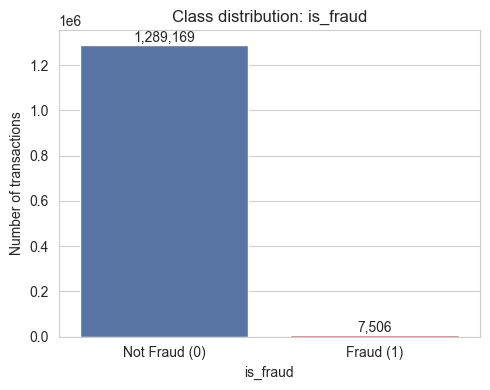

Fraud rate: 0.579% of all transactions


In [13]:
fraud_counts = train["is_fraud"].value_counts()

plt.figure(figsize=(5, 4))
ax = sns.barplot(x=fraud_counts.index, y=fraud_counts.values, palette=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["Not Fraud (0)", "Fraud (1)"])
ax.set_ylabel("Number of transactions")
ax.set_title("Class distribution: is_fraud")
for i, v in enumerate(fraud_counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

fraud_rate = fraud_counts[1] / fraud_counts.sum() * 100
print(f"Fraud rate: {fraud_rate:.3f}% of all transactions")


## 5. Feature engineering from datetime columns

Extract `hour`, `day`, `month`, `day_of_week` from the transaction timestamp, and compute cardholder `age` from date of birth.

In [14]:
train["trans_date_trans_time"] = pd.to_datetime(train["trans_date_trans_time"])
train["dob"] = pd.to_datetime(train["dob"])


In [15]:
test["trans_date_trans_time"] = pd.to_datetime(test["trans_date_trans_time"])
test["dob"] = pd.to_datetime(test["dob"])


In [16]:
train["hour"] = train["trans_date_trans_time"].dt.hour
train["day"] = train["trans_date_trans_time"].dt.day
train["month"] = train["trans_date_trans_time"].dt.month
train["day_of_week"] = train["trans_date_trans_time"].dt.dayofweek

train["age"] = (
    train["trans_date_trans_time"].dt.year
    - train["dob"].dt.year
)


In [17]:
test["hour"] = test["trans_date_trans_time"].dt.hour
test["day"] = test["trans_date_trans_time"].dt.day
test["month"] = test["trans_date_trans_time"].dt.month
test["day_of_week"] = test["trans_date_trans_time"].dt.dayofweek

test["age"] = (
    test["trans_date_trans_time"].dt.year
    - test["dob"].dt.year
)


In [18]:
train.head()


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,trans_num,unix_time,merch_lat,merch_long,is_fraud,hour,day,month,day_of_week,age
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,0,1,1,1,31
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,0,1,1,1,41
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,0,1,1,1,57
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,0,1,1,1,52
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,0,1,1,1,33


In [19]:
test.head()


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,trans_num,unix_time,merch_lat,merch_long,is_fraud,hour,day,month,day_of_week,age
0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,...,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0,12,21,6,6,52
1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,...,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0,12,21,6,6,30
2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,...,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0,12,21,6,6,50
3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,...,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0,12,21,6,6,33
4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,...,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0,12,21,6,6,65


In [20]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 27 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   trans_date_trans_time  1296675 non-null  datetime64[ns]
 1   cc_num                 1296675 non-null  int64         
 2   merchant               1296675 non-null  object        
 3   category               1296675 non-null  object        
 4   amt                    1296675 non-null  float64       
 5   first                  1296675 non-null  object        
 6   last                   1296675 non-null  object        
 7   gender                 1296675 non-null  object        
 8   street                 1296675 non-null  object        
 9   city                   1296675 non-null  object        
 10  state                  1296675 non-null  object        
 11  zip                    1296675 non-null  int64         
 12  lat                    12966

In [21]:
test.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   trans_date_trans_time  555719 non-null  datetime64[ns]
 1   cc_num                 555719 non-null  int64         
 2   merchant               555719 non-null  object        
 3   category               555719 non-null  object        
 4   amt                    555719 non-null  float64       
 5   first                  555719 non-null  object        
 6   last                   555719 non-null  object        
 7   gender                 555719 non-null  object        
 8   street                 555719 non-null  object        
 9   city                   555719 non-null  object        
 10  state                  555719 non-null  object        
 11  zip                    555719 non-null  int64         
 12  lat                    555719 non-null  floa

## 6. Drop identifier / non-predictive columns

In [22]:
train.drop(columns=["trans_num","first","last","cc_num","street","dob","trans_date_trans_time","unix_time","zip"], axis=1, inplace=True)
test.drop(columns=["trans_num","first","last","cc_num","street","dob","trans_date_trans_time","unix_time","zip"], axis=1, inplace=True)


In [23]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 18 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   merchant     1296675 non-null  object 
 1   category     1296675 non-null  object 
 2   amt          1296675 non-null  float64
 3   gender       1296675 non-null  object 
 4   city         1296675 non-null  object 
 5   state        1296675 non-null  object 
 6   lat          1296675 non-null  float64
 7   long         1296675 non-null  float64
 8   city_pop     1296675 non-null  int64  
 9   job          1296675 non-null  object 
 10  merch_lat    1296675 non-null  float64
 11  merch_long   1296675 non-null  float64
 12  is_fraud     1296675 non-null  int64  
 13  hour         1296675 non-null  int32  
 14  day          1296675 non-null  int32  
 15  month        1296675 non-null  int32  
 16  day_of_week  1296675 non-null  int32  
 17  age          1296675 non-null  int32  
dtypes:

In [24]:
test.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   merchant     555719 non-null  object 
 1   category     555719 non-null  object 
 2   amt          555719 non-null  float64
 3   gender       555719 non-null  object 
 4   city         555719 non-null  object 
 5   state        555719 non-null  object 
 6   lat          555719 non-null  float64
 7   long         555719 non-null  float64
 8   city_pop     555719 non-null  int64  
 9   job          555719 non-null  object 
 10  merch_lat    555719 non-null  float64
 11  merch_long   555719 non-null  float64
 12  is_fraud     555719 non-null  int64  
 13  hour         555719 non-null  int32  
 14  day          555719 non-null  int32  
 15  month        555719 non-null  int32  
 16  day_of_week  555719 non-null  int32  
 17  age          555719 non-null  int32  
dtypes: float64(5), int32(5),

Drop any remaining rows with nulls introduced by the datetime parsing or feature engineering steps.

In [25]:
train.dropna(inplace=True)
test.dropna(inplace=True)


In [26]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 18 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   merchant     1296675 non-null  object 
 1   category     1296675 non-null  object 
 2   amt          1296675 non-null  float64
 3   gender       1296675 non-null  object 
 4   city         1296675 non-null  object 
 5   state        1296675 non-null  object 
 6   lat          1296675 non-null  float64
 7   long         1296675 non-null  float64
 8   city_pop     1296675 non-null  int64  
 9   job          1296675 non-null  object 
 10  merch_lat    1296675 non-null  float64
 11  merch_long   1296675 non-null  float64
 12  is_fraud     1296675 non-null  int64  
 13  hour         1296675 non-null  int32  
 14  day          1296675 non-null  int32  
 15  month        1296675 non-null  int32  
 16  day_of_week  1296675 non-null  int32  
 17  age          1296675 non-null  int32  
dtypes:

In [27]:
test.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   merchant     555719 non-null  object 
 1   category     555719 non-null  object 
 2   amt          555719 non-null  float64
 3   gender       555719 non-null  object 
 4   city         555719 non-null  object 
 5   state        555719 non-null  object 
 6   lat          555719 non-null  float64
 7   long         555719 non-null  float64
 8   city_pop     555719 non-null  int64  
 9   job          555719 non-null  object 
 10  merch_lat    555719 non-null  float64
 11  merch_long   555719 non-null  float64
 12  is_fraud     555719 non-null  int64  
 13  hour         555719 non-null  int32  
 14  day          555719 non-null  int32  
 15  month        555719 non-null  int32  
 16  day_of_week  555719 non-null  int32  
 17  age          555719 non-null  int32  
dtypes: float64(5), int32(5),

## 7. EDA

**Transaction amount vs. fraud.**

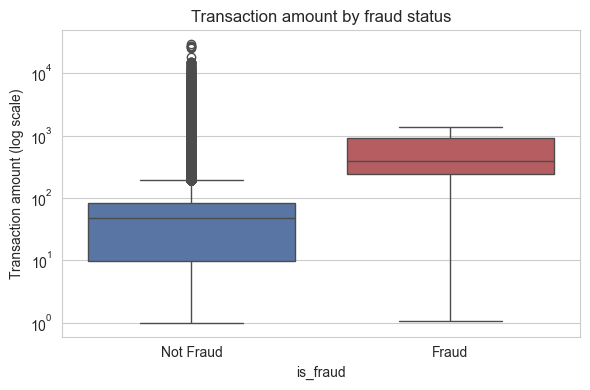

In [28]:
plt.figure(figsize=(6, 4))
sns.boxplot(x="is_fraud", y="amt", data=train, palette=["#4C72B0", "#C44E52"])
plt.yscale("log")
plt.xticks([0, 1], ["Not Fraud", "Fraud"])
plt.ylabel("Transaction amount (log scale)")
plt.title("Transaction amount by fraud status")
plt.tight_layout()
plt.show()


**Fraud rate by hour of day.**

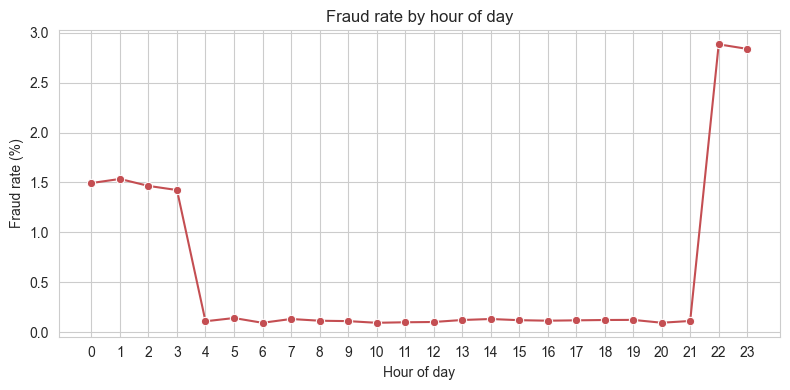

In [29]:
fraud_by_hour = train.groupby("hour")["is_fraud"].mean() * 100

plt.figure(figsize=(8, 4))
sns.lineplot(x=fraud_by_hour.index, y=fraud_by_hour.values, marker="o", color="#C44E52")
plt.xlabel("Hour of day")
plt.ylabel("Fraud rate (%)")
plt.title("Fraud rate by hour of day")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()


**Correlation heatmap.**

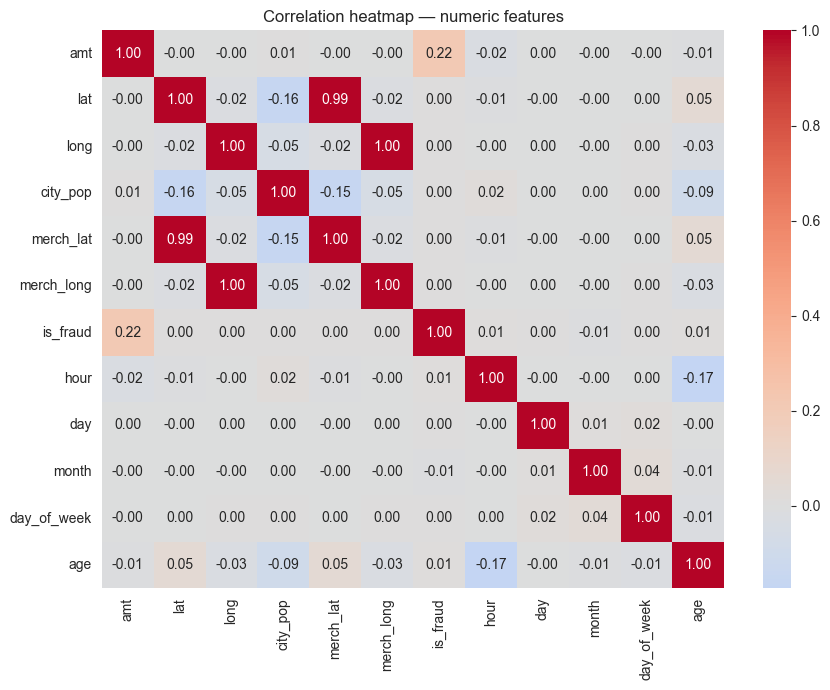

In [30]:
numeric_preview = train.select_dtypes(include=["int64", "int32", "float64"])

plt.figure(figsize=(9, 7))
sns.heatmap(numeric_preview.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation heatmap — numeric features")
plt.tight_layout()
plt.show()


## 8. Inspecting column types before encoding

In [31]:
train.select_dtypes(["int64","int32","float64"]).head()


,amt,lat,long,city_pop,merch_lat,merch_long,is_fraud,hour,day,month,day_of_week,age
0,4.97,36.0788,-81.1781,3495,36.011293,-82.048315,0,0,1,1,1,31
1,107.23,48.8878,-118.2105,149,49.159047,-118.186462,0,0,1,1,1,41
2,220.11,42.1808,-112.2620,4154,43.150704,-112.154481,0,0,1,1,1,57
3,45.00,46.2306,-112.1138,1939,47.034331,-112.561071,0,0,1,1,1,52
4,41.96,38.4207,-79.4629,99,38.674999,-78.632459,0,0,1,1,1,33


In [32]:
test.select_dtypes(["int64","int32","float64"]).head()


,amt,lat,long,city_pop,merch_lat,merch_long,is_fraud,hour,day,month,day_of_week,age
0,2.86,33.9659,-80.9355,333497,33.986391,-81.200714,0,12,21,6,6,52
1,29.84,40.3207,-110.4360,302,39.450498,-109.960431,0,12,21,6,6,30
2,41.28,40.6729,-73.5365,34496,40.495810,-74.196111,0,12,21,6,6,50
3,60.05,28.5697,-80.8191,54767,28.812398,-80.883061,0,12,21,6,6,33
4,3.19,44.2529,-85.0170,1126,44.959148,-85.884734,0,12,21,6,6,65


In [33]:
train.select_dtypes('O').head()


,merchant,category,gender,city,state,job
0,"fraud_Rippin, Kub and Mann",misc_net,F,Moravian Falls,NC,"Psychologist, counselling"
1,"fraud_Heller, Gutmann and Zieme",grocery_pos,F,Orient,WA,Special educational needs teacher
2,fraud_Lind-Buckridge,entertainment,M,Malad City,ID,Nature conservation officer
3,"fraud_Kutch, Hermiston and Farrell",gas_transport,M,Boulder,MT,Patent attorney
4,fraud_Keeling-Crist,misc_pos,M,Doe Hill,VA,Dance movement psychotherapist


In [34]:
test.select_dtypes('O').head()


,merchant,category,gender,city,state,job
0,fraud_Kirlin and Sons,personal_care,M,Columbia,SC,Mechanical engineer
1,fraud_Sporer-Keebler,personal_care,F,Altonah,UT,"Sales professional, IT"
2,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,F,Bellmore,NY,"Librarian, public"
3,fraud_Haley Group,misc_pos,M,Titusville,FL,Set designer
4,fraud_Johnston-Casper,travel,M,Falmouth,MI,Furniture designer


## 9. Encode categorical columns

- `gender` → binary map (already only 2 categories)
- `category` (14 unique) and `state` (~50 unique) → one-hot encoding (`drop_first=True` to avoid the dummy trap)
- `merchant`, `city`, `job` (100s of unique values each) → **frequency encoding**, since one-hot would create thousands of sparse columns. This is fit later, on the training split only (see next section) to avoid leaking validation-fold distribution info.

In [35]:
train.gender = train.gender.map({'M': 1, "F": 0})
test.gender = test.gender.map({'M': 1, "F": 0})


In [36]:
train = pd.get_dummies(train, columns=["category", "state"], drop_first=True)
test = pd.get_dummies(test, columns=["category", "state"], drop_first=True)


## 10. Train-Test Split

In [37]:
from sklearn.model_selection import train_test_split

X = train.drop(columns=["is_fraud"], axis=1)
y = train["is_fraud"]

train_X, test_X, train_y, test_y = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


### Frequency encoding `merchant`, `city`, `job`

Fit the frequency map on `train_X` only, then apply it to `test_X` and to the true holdout `test` set. Unseen categories in either get mapped to `0` (never seen in training → treated as maximally rare).

In [38]:
freq_cols = ['merchant', 'city', 'job']
freq_maps = {}

for col in freq_cols:
    freq = train_X[col].value_counts(normalize=True)
    freq_maps[col] = freq

    train_X[col] = train_X[col].map(freq)
    test_X[col] = test_X[col].map(freq).fillna(0)
    test[col] = test[col].map(freq).fillna(0)


## 11. Numeric feature preprocessing

- `amt`, `city_pop` are heavily right-skewed → log-transform (`log1p`) before scaling.
- `hour`, `day`, `month`, `day_of_week` are cyclical, not linear (hour 23 and hour 0 are adjacent) → sin/cos transform instead of treating them as plain scaled numbers.

In [39]:
def preprocess(df):
    df = df.copy()

    if 'amt' in df.columns:
        df['amt_log'] = np.log1p(df['amt'])
        df = df.drop(columns=['amt'])

    if 'city_pop' in df.columns:
        df['city_pop_log'] = np.log1p(df['city_pop'])
        df = df.drop(columns=['city_pop'])

    for col, period in [('hour', 24), ('day', 31), ('month', 12), ('day_of_week', 7)]:
        if col in df.columns:
            df[f'{col}_sin'] = np.sin(2 * np.pi * df[col] / period)
            df[f'{col}_cos'] = np.cos(2 * np.pi * df[col] / period)
            df = df.drop(columns=[col])

    if 'is_fraud' in df.columns:
        df['is_fraud'] = df['is_fraud'].astype(int)

    return df

train_X = preprocess(train_X)
test_X = preprocess(test_X)
test = preprocess(test)


## 12. Scale numeric features (fit on train only)

In [40]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['lat', 'long', 'merch_lat', 'merch_long', 'age', 'amt_log', 'city_pop_log']

scaler = StandardScaler()
train_X[numeric_cols] = scaler.fit_transform(train_X[numeric_cols])
test_X[numeric_cols] = scaler.transform(test_X[numeric_cols])
test[numeric_cols] = scaler.transform(test[numeric_cols])


## 13. Handle class imbalance with SMOTE

In [41]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
train_X, train_y = sm.fit_resample(train_X, train_y)

print("Class balance after SMOTE:")
print(train_y.value_counts())


Class balance after SMOTE:
is_fraud
0    1031335
1    1031335
Name: count, dtype: int64


## 14. Training and comparing models

In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, f1_score, precision_score, recall_score, accuracy_score


### Logistic Regression

In [43]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(train_X, train_y)
pred_lr = lr.predict(test_X)
prob_lr = lr.predict_proba(test_X)[:, 1]

print("Classification Report:\n", classification_report(test_y, pred_lr))
print("ROC AUC Score:", roc_auc_score(test_y, prob_lr))


Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.93      0.96    257834
           1       0.05      0.67      0.10      1501

    accuracy                           0.93    259335
   macro avg       0.53      0.80      0.53    259335
weighted avg       0.99      0.93      0.96    259335

ROC AUC Score: 0.8893479418611927


### Random Forest

In [44]:
rf = RandomForestClassifier(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)
rf.fit(train_X, train_y)
pred_rf = rf.predict(test_X)
prob_rf = rf.predict_proba(test_X)[:, 1]

print("Classification Report:\n", classification_report(test_y, pred_rf))
print("ROC AUC Score:", roc_auc_score(test_y, prob_rf))


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.51      0.86      0.64      1501

    accuracy                           0.99    259335
   macro avg       0.75      0.93      0.82    259335
weighted avg       1.00      0.99      1.00    259335

ROC AUC Score: 0.9901753121222034


### XGBoost

In [45]:
xgb = XGBClassifier(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42, eval_metric="logloss")
xgb.fit(train_X, train_y)
pred_xgb = xgb.predict(test_X)
prob_xgb = xgb.predict_proba(test_X)[:, 1]

print("Classification Report:\n", classification_report(test_y, pred_xgb))
print("ROC AUC Score:", roc_auc_score(test_y, prob_xgb))


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.95      0.88      0.91      1501

    accuracy                           1.00    259335
   macro avg       0.97      0.94      0.96    259335
weighted avg       1.00      1.00      1.00    259335

ROC AUC Score: 0.9993287310852444


**Visual 5 — Model comparison.**

,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.052826,0.665556,0.097884,0.889348
Random Forest,0.509120,0.855430,0.638330,0.990175
XGBoost,0.948239,0.878748,0.912172,0.999329


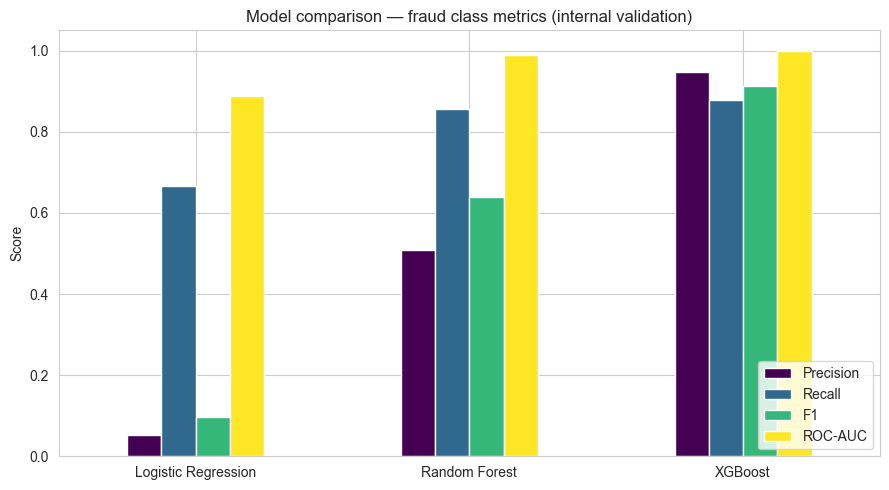

In [46]:
results = {
    "Logistic Regression": (pred_lr, prob_lr),
    "Random Forest": (pred_rf, prob_rf),
    "XGBoost": (pred_xgb, prob_xgb),
}

metrics_df = pd.DataFrame({
    name: {
        "Precision": precision_score(test_y, pred),
        "Recall": recall_score(test_y, pred),
        "F1": f1_score(test_y, pred),
        "ROC-AUC": roc_auc_score(test_y, prob),
    }
    for name, (pred, prob) in results.items()
}).T

display(metrics_df)

metrics_df.plot(kind="bar", figsize=(9, 5), colormap="viridis")
plt.title("Model comparison — fraud class metrics (internal validation)")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


Based on this comparison, XGBoost is the strongest model and will be used for prediction on test datset.

## 15. Final evaluation on test dataset 

In [47]:
X_final_test = test.drop(columns=["is_fraud"], axis=1)
y_final_test = test["is_fraud"]

X_final_test = X_final_test.reindex(columns=train_X.columns, fill_value=0)


In [48]:
pred_final = xgb.predict(X_final_test)
prob_final = xgb.predict_proba(X_final_test)[:, 1]

print(classification_report(y_final_test, pred_final))
print("ROC AUC Score:", roc_auc_score(y_final_test, prob_final))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.91      0.76      0.83      2145

    accuracy                           1.00    555719
   macro avg       0.96      0.88      0.92    555719
weighted avg       1.00      1.00      1.00    555719

ROC AUC Score: 0.9946302830979495


## 16. Feature importance (XGBoost)

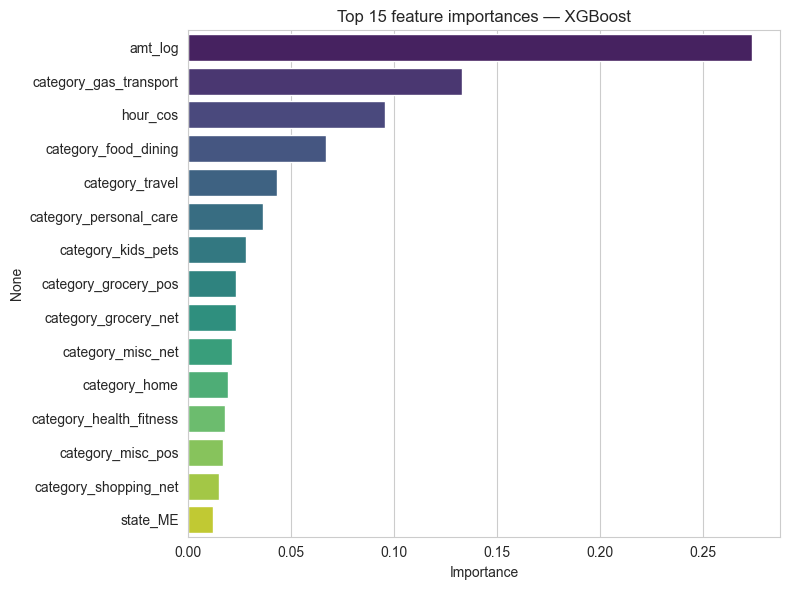

In [49]:
importances = pd.Series(xgb.feature_importances_, index=train_X.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Top 15 feature importances — XGBoost")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 17. Saving Model

In [51]:
import joblib

joblib.dump(xgb, "credit_card_fraud.pkl")
joblib.dump(scaler, "scaler.pkl")
print("Saved: credit_card_fraud.pkl, scaler.pkl")


Saved: credit_card_fraud.pkl, scaler.pkl
